In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

In [4]:
def latin_hypercube_uniform(vars, strats, lim, mean=0, plot=False):
    lower_limits = np.linspace(mean-lim, mean+lim, strats, endpoint=False)
    upper_limits = lower_limits + (lower_limits[1] - lower_limits[0])
    ticks = np.append(lower_limits, upper_limits)
    
    points = np.zeros((strats, vars))
    for i in range(vars):
        points[:, i] = np.random.uniform(lower_limits, upper_limits, size=strats)
        np.random.shuffle(points[:, i])
    if plot:
        plot_LHS(points, lim, ticks)
    return points

def plot_LHS(p, lim, ticks, dims=[0, 1]):
    plt.figure(figsize=(6, 6))
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)
    plt.xticks(ticks)
    plt.yticks(ticks)
    plt.xlabel("$\Delta x_i$")
    plt.ylabel("$\Delta y_i$")
    plt.scatter(p[:, dims[0]], p[:, dims[1]], c="r")
    plt.grid()
    plt.show()

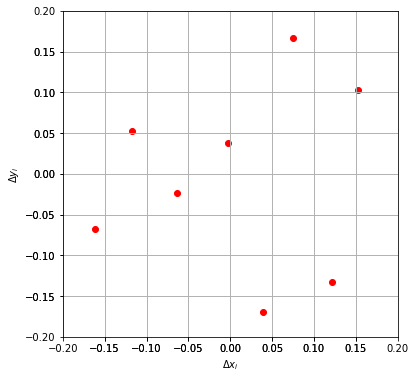

In [5]:
points = latin_hypercube_uniform(vars=4, strats=8, lim=0.2, plot=True)

In [28]:
sampler = qmc.LatinHypercube(d=4, optimization="random-cd")
sample = sampler.random(n=20)
print(sample, "\n", qmc.scale(sample, -0.2, 0.2))
print(qmc.discrepancy(sample))

[[0.04923024 0.86701385 0.4874232  0.57954678]
 [0.05002135 0.0848537  0.16904951 0.37879634]
 [0.93846441 0.90618962 0.76468998 0.42988545]
 [0.82976535 0.15462868 0.59115915 0.17551209]
 [0.71409184 0.75123129 0.21877971 0.72041532]
 [0.45636069 0.01377905 0.64466678 0.83048185]
 [0.26170212 0.9774728  0.27084853 0.21251657]
 [0.19249129 0.4204232  0.88334291 0.05197238]
 [0.87399379 0.53854912 0.1178828  0.90774809]
 [0.65086723 0.56484042 0.50278354 0.01069208]
 [0.24831838 0.26606668 0.4032758  0.98314496]
 [0.99901342 0.33604566 0.36723663 0.28185649]
 [0.62747858 0.11681584 0.06207368 0.51365448]
 [0.13190601 0.63019114 0.72551148 0.7512159 ]
 [0.33642554 0.4683532  0.31711771 0.63721087]
 [0.75803492 0.37877752 0.82520217 0.67894551]
 [0.3658799  0.23832297 0.96991869 0.46012815]
 [0.42524644 0.72787141 0.02835329 0.10231783]
 [0.52881622 0.84080366 0.90190701 0.8754284 ]
 [0.55896719 0.66936182 0.69650435 0.32169279]] 
 [[-0.1803079   0.14680554 -0.00503072  0.03181871]
 [-0.1

In [ ]:
def latin_hypercube_uniform(vars, strats, lim, mean=0, plot=False, refined=False):
    lower_limits = np.linspace(mean-lim, mean+lim, strats, endpoint=False)
    upper_limits = lower_limits + (lower_limits[1] - lower_limits[0])
    
    xticks, yticks = np.append(lower_limits, upper_limits), np.append(lower_limits, upper_limits)

    if refined:

        for i, lims in enumerate(refined):
            lower_limits_ = np.linspace(lims[0], lims[1], strats, endpoint=False)
            upper_limits_ = lower_limits_ + (lower_limits_[1] - lower_limits_[0])

            ticks_ = np.append(lower_limits_, upper_limits_)
            if i == 0:
                xticks = np.append(xticks, ticks_)
            elif i == 1:
                yticks = np.append(yticks, ticks_)
    ticks = np.array([xticks, yticks])
    
    print(upper_limits, lower_limits)

    points = np.zeros((strats, vars))
    for i in range(vars):
        points[:, i] = np.random.uniform(lower_limits, upper_limits, size=strats)
        np.random.shuffle(points[:, i])
    
    if plot:
        plot_LHS(points, lim, ticks)

    return points

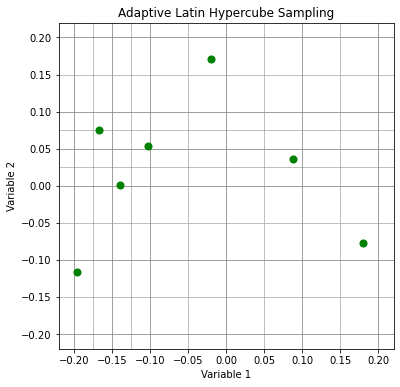

array([[-0.02065353,  0.1704109 ],
       [-0.16712369,  0.07563838],
       [-0.10243667,  0.05417506],
       [-0.14025716,  0.00036543],
       [ 0.08793032,  0.03580583],
       [-0.19549829, -0.11628244],
       [ 0.1797016 , -0.07738184]])

In [305]:
import numpy as np
import matplotlib.pyplot as plt

def adaptive_LHS_custom(intervals_var1, intervals_var2):
    num_samples = len(intervals_var1)
    assert num_samples == len(intervals_var2), "Must have equal total intervals per dimension."

    points = np.zeros((num_samples, 2))

    # Variable 1 Sampling
    for i, (low, high) in enumerate(intervals_var1):
        points[i, 0] = np.random.uniform(low, high)

    # Shuffle to maintain randomness in pairing
    np.random.shuffle(points[:, 0])

    # Variable 2 Sampling
    for i, (low, high) in enumerate(intervals_var2):
        points[i, 1] = np.random.uniform(low, high)

    # Shuffle again independently
    np.random.shuffle(points[:, 1])

    return points

def plot_custom_LHS(points, intervals_var1, intervals_var2):
    plt.figure(figsize=(6, 6))

    # Plot points
    plt.scatter(points[:,0], points[:,1], c="g", s=50, zorder=5)

    # Variable 1 gridlines
    var1_lines = sorted(set([x for interval in intervals_var1 for x in interval]))
    for x in var1_lines:
        plt.axvline(x, color='grey', linewidth=0.5)

    # Variable 2 gridlines
    var2_lines = sorted(set([y for interval in intervals_var2 for y in interval]))
    for y in var2_lines:
        plt.axhline(y, color='grey', linewidth=0.5)

    plt.xlabel("Variable 1")
    plt.ylabel("Variable 2")
    plt.title("Adaptive Latin Hypercube Sampling")
    plt.grid(True)
    plt.show()

# Explicitly define your refined intervals
intervals_var1 = [(-0.2, -0.175), (-0.175, -0.15), (-0.15, -0.125),
                  (-0.125, -0.1), (-0.1, 0.0), (0.0, 0.1), (0.1, 0.2)]

intervals_var2 = [(-0.2, -0.1), (-0.1, 0.0), (0.0, 0.025),
                  (0.025, 0.05), (0.05, 0.075), (0.075, 0.1), (0.1, 0.2)]

# Generate points explicitly
points = adaptive_LHS_custom(intervals_var1, intervals_var2)

# Plot the points clearly
plot_custom_LHS(points, intervals_var1, intervals_var2)
points
